In [1]:
import numpy as np
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import confusion_matrix, classification_report

I0000 00:00:1789225062.263631    1816 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1789225062.305146    1816 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1789225063.594489    1816 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [8]:
from tensorflow import keras
from tensorflow.keras.regularizers import l2
from PIL import Image
model = keras.models.load_model("cnn_model.keras")

In [9]:
with open("all.json", "r") as file:
    data = json.load(file)

In [10]:
X = []
y = []

In [11]:
for category in data:
    for image in data[category]:
        img = Image.open(f"./all/{image}")
        img = img.convert("RGB")
        img = img.resize((224, 224))
        img_array = np.array(img)
        X.append(img_array)
        y.append(category)

/home/shashi/miniconda3/envs/tensorflow/lib/python3.11/site-packages/PIL/Image.py:1136: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


In [12]:
X = np.array(X)
y = np.array(y)

In [16]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

y = encoder.fit_transform(y)

In [17]:
# First split: 80% training+validation, 20% testing
from sklearn.model_selection import train_test_split
X_temp, X_test, y_temp, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Second split: training and validation
X_train, X_val, y_train, y_val = train_test_split(
    X_temp,
    y_temp,
    test_size=0.20,
    random_state=42,
    stratify=y_temp
)

print("Training images:", X_train.shape)
print("Validation images:", X_val.shape)
print("Testing images:", X_test.shape)

print("\nNumber of classes:", len(encoder.classes_))
print("Classes:", encoder.classes_)

Training images: (7680, 224, 224, 3)
Validation images: (1920, 224, 224, 3)
Testing images: (2400, 224, 224, 3)

Number of classes: 2
Classes: [0 1]


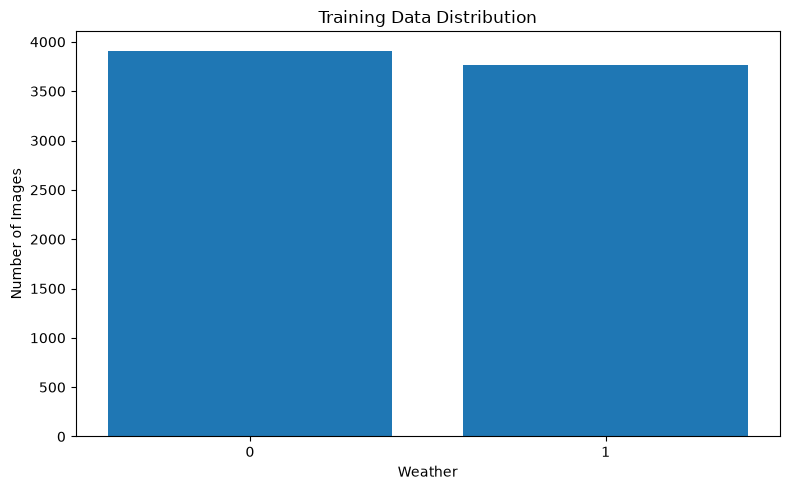

In [18]:
classes, counts = np.unique(y_train, return_counts=True)

plt.figure(figsize=(8, 5))
plt.bar(classes, counts)
plt.xlabel("Weather")
plt.ylabel("Number of Images")
plt.title("Training Data Distribution")
plt.tight_layout()
plt.xticks(classes)
plt.show()

In [19]:
test_loss, test_accuracy = model.evaluate(
    X_test,
    y_test,
    verbose=0
)

print("\nTesting Loss    :", test_loss)
print("Testing Accuracy:", test_accuracy)


Testing Loss    : 0.21009241044521332
Testing Accuracy: 0.9412500262260437


In [21]:
y_pred_probability = model.predict(X_test)
y_pred = np.argmax(y_pred_probability, axis=1)

75/75 ━━━━━━━━━━━━━━━━━━━━ 11s 137ms/step


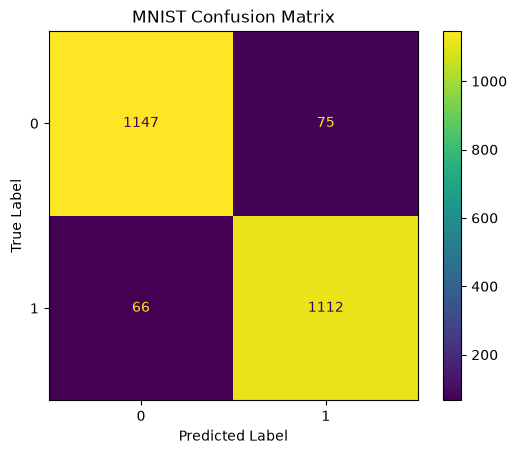

In [22]:
from sklearn.metrics import ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)

ConfusionMatrixDisplay(cm).plot()
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("MNIST Confusion Matrix")
plt.show()